## TP1, Procesamiento de Datos
### Sol Josefina Mercado, dni: 38.442.698

1. Extracción e Ingesta de Datos  

In [182]:
# seteo del path para que el notebook pueda ingresar al resto de las carpetas
import sys
from pathlib import Path

RAIZ = Path.cwd().parent  
if str(RAIZ) not in sys.path:
    sys.path.append(str(RAIZ))

In [183]:
# carga de la configuracion en yaml
from utils.configuracion import cargar_config
config = cargar_config(str(RAIZ / "config" / "config.yaml"))


In [184]:
# lectura del dataframe con pandas por ruta en config 
import pandas as pd
# ubicacion del csv
ruta_bronze = RAIZ / config["rutas"]["bronze"]
# lectura
df = pd.read_csv(ruta_bronze, encoding="latin-1")

Primer paneo del dataset con el que debo trabajar, aqui puedo ver el contenido de cada columna para comenzar a entender como esta organizado el df y que informacion será posible extraer 

In [185]:
df.head(2)

,Dis No,Year,Seq,Glide,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,Disaster Subsubtype,Event Name,...,No Homeless,Total Affected,Reconstruction Costs ('000 US$),Insured Damages ('000 US$),Total Damages ('000 US$),CPI,Adm Level,Admin1 Code,Admin2 Code,Geo Locations
0,1970-0013-ARG,1970,13,NaN,Natural,Hydrological,Flood,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,25000.0,15.001282,NaN,NaN,NaN,NaN
1,1970-0109-AUS,1970,109,NaN,Natural,Meteorological,Storm,Tropical cyclone,NaN,Ada,...,NaN,NaN,NaN,NaN,72475.0,15.001282,NaN,NaN,NaN,NaN


Exploración inicial de la estructura del dataset (shape, info, describe)

In [186]:
print("Shape: filas y columnas:", df.shape)

Shape: filas y columnas: (14644, 47)


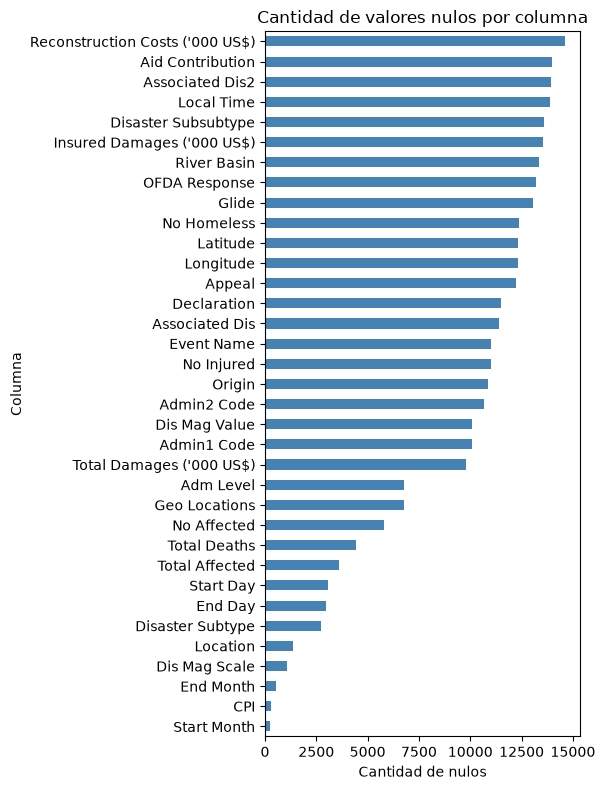

In [187]:
# grafico de valores nulos por columna 

import seaborn as sns
import matplotlib.pyplot as plt

nulos = df.isnull().sum().sort_values(ascending=False)
# solo las columnas que tienen algún nulo
nulos = nulos[nulos > 0]  

fig, ax = plt.subplots(figsize=(6, 8))
nulos.plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()  # para que la columna con más nulos quede arriba
ax.set_title("Cantidad de valores nulos por columna")
ax.set_xlabel("Cantidad de nulos")
ax.set_ylabel("Columna")
fig.tight_layout()

In [188]:
print('--------- Info ---------')
print(df.info())

--------- Info ---------
<class 'pandas.DataFrame'>
RangeIndex: 14644 entries, 0 to 14643
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Dis No                           14644 non-null  str    
 1   Year                             14644 non-null  int64  
 2   Seq                              14644 non-null  int64  
 3   Glide                            1581 non-null   str    
 4   Disaster Group                   14644 non-null  str    
 5   Disaster Subgroup                14644 non-null  str    
 6   Disaster Type                    14644 non-null  str    
 7   Disaster Subtype                 11897 non-null  str    
 8   Disaster Subsubtype              1044 non-null   str    
 9   Event Name                       3645 non-null   str    
 10  Country                          14644 non-null  str    
 11  ISO                              14644 non-null  str    
 12  Regi

## A partir de aqui voy a hacer un analisis sobre las variables que las consignas me exigen procesar:

Columnas con fechas (Requiere imputacion de nulos)
* Year
* Start Day, Month, Year
* End Day, Month, Year

Columnas con datos sobre los eventos:
* 'Disaster Group'
* 'Disaster Subgroup'
* 'Disaster Type'
* 'Disaster Subtype'
* 'Disaster Subsubtype',
* 'Event Name'

Columnas con datos de ubicacion: 
* 'Country'
* 'Region'
* 'Continent'
* 'Location'
* 'Geo locations'



In [189]:
df_selected_columns = df[['Year', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month',
       'End Day','Disaster Group', 'Disaster Subgroup',
       'Disaster Type', 'Disaster Subtype', 'Disaster Subsubtype',
       'Event Name', 'Country', 'Region', 'Continent', 'Location','Geo Locations' ]].copy()

# convierto a minuscula y reemplazo espacios en nombre de columnas
df_selected_columns.columns = df_selected_columns.columns.str.lower().str.replace(" ", "_")

### ¿Las columnas 'year' y 'start_year' son iguales?
Con 14522 cohincidencias, asumo que es una columna duplicada, conservo 'start_year' ya que no tiene nulos, y está emparejada con start_month y start_day para conformar la columna unica 'fecha'.

In [190]:
cantidad_igual = (df_selected_columns["year"] == df_selected_columns["start_year"]).value_counts()
print('Cantidad de columnas duplicadas')
print(cantidad_igual)

distintas = df_selected_columns[df_selected_columns["year"] != df_selected_columns["start_year"]]
print(distintas[["year", "start_year"]])

Cantidad de columnas duplicadas
True     14522
False      122
Name: count, dtype: int64
       year  start_year
199    1976        1977
222    1976        1977
430    1973        1974
528    1976        1978
545    1976        1977
...     ...         ...
13990  2019        2020
14071  2019        2020
14198  2020        2021
14223  2020        2021
14504  2019        2020

[122 rows x 2 columns]


In [191]:
df_selected_columns.drop(columns='year', inplace=True)

### Estadisticas basicas sobre las columnas cuantitativas.
* Los registros comienzan en 1970 start_year.min() y finalizan en 2021. El recorte de los ultimos 20 años abarcará desde 2001 a 2021.
* En start_year el valor de media (mean 2001.606323) y de mediana (50% 2003.000000) son cercanos lo queindica que los eventos estan repartidos sin una acumulacion de eventos en algun año particular.
* start_day tiene minimo de 1 y maximo de 31, lo que indica que no hay valores corruptos.
* start_year y end_year no tienen valores nulos (count 14644) las columnas para mes y dia si contienen valores faltantes que deberán ser imputados.

### descarto las columnas de end_ ya que debo conformar una unica columna de fecha
Los valores de start y end son practicamente los mismos, con lo que infiero que los desastres son de corta duracion y con la informacion de año y mes de inicio ya obtengo precision en cuanto a ubicar en tiempo el evento


In [192]:
print(df_selected_columns.describe())

         start_year   start_month     start_day      end_year     end_month  \
count  14644.000000  14376.000000  11577.000000  14644.000000  14095.000000   
mean    2001.606323      6.411241     15.207912   2001.655763      6.549273   
std       12.535872      3.393997      8.964592     12.537387      3.351351   
min     1970.000000      1.000000      1.000000   1970.000000      1.000000   
25%     1993.000000      4.000000      7.000000   1993.000000      4.000000   
50%     2003.000000      7.000000     15.000000   2003.000000      7.000000   
75%     2012.000000      9.000000     23.000000   2012.000000      9.000000   
max     2021.000000     12.000000     31.000000   2021.000000     12.000000   

            end_day  
count  11650.000000  
mean      15.792618  
std        8.872079  
min        1.000000  
25%        8.000000  
50%       16.000000  
75%       24.000000  
max       31.000000  


In [193]:
df_selected_columns.drop(columns=['end_year', 'end_month', 'end_day'], inplace=True)

## Descripcion de las variables cualitativas
### columnas con datos sobre eventos: 
* disastrer_group solo existe un valor: Natural.
* disaster_subgroup 6 valores unicos, 6 tipos de subgrupos, siendo el mas frecuente Hydrological.
* disaster_type tiene 14 tipos de desastres registrados, Inundacion es el mas frecuente.
### columnas con datos de localizacion:
* 228 Paises, donde Estados unidos es el country que mas registros tiene.
* 23 regiones, Region con mas registros es Southern Asia.
* 5 continentes, Asia con mayor cantidad de registros. 

(En Asia se concentran la cantidad de eventos si filtramos por continente o region, 
y a nivel Country, estados unidos es quien mas desastres cuenta.
Osea que en Asia ocurren eventos mas dipersos sobre la zona, sin estar focalizados en un pais)

### descarto las columnas: 
* disaster_group (posee un unico dato), 
* disaster_subtype, disaster_subsubtype (informacion contenida en disaster_type para este analisis)
* event_name contiene los nombres de los fenomenos, son demasiados y no aporta informacion extra para este analisis
* geolocations contiene los nombres de las ciudades
* locations contiene los nombres de las municipalidades



In [194]:
display(df_selected_columns.describe(include=str))

,disaster_group,disaster_subgroup,disaster_type,disaster_subtype,disaster_subsubtype,event_name,country,region,continent,location,geo_locations
count,14644,14644,14644,11897,1044,3645,14644,14644,14644,13298,7855
unique,1,6,14,27,12,1488,228,23,5,11995,6354
top,Natural,Hydrological,Flood,Riverine flood,Tornado,Cholera,United States of America (the),Southern Asia,Asia,North,Administrative unit not available (Adm1).
freq,14644,5985,5272,2633,264,481,949,1849,5793,37,93


In [195]:
columnas_descarte = ['disaster_group', 'disaster_subtype','disaster_subsubtype','event_name','geo_locations','location']
df_selected_columns.drop(columns=columnas_descarte, inplace=True)

## inspeccion de las columnas seleccionadas para cruces de informacion y generacion de reportes

Recorte temporal (ultimos 20 años)
(Esto debe guardarse en path silver)

In [196]:
anio_max = df_selected_columns["start_year"].max()
print('ultimo registro:', anio_max)
print()
print('Recorte ultimos 20 años')

# df_reciente contiene el recorte de los ultimo 20 años solicitados
df_analisis = df_selected_columns[df_selected_columns["start_year"] >= anio_max - 19].copy().reset_index(drop=True)
df_analisis.head()

ultimo registro: 2021

Recorte ultimos 20 años


,start_year,start_month,start_day,disaster_subgroup,disaster_type,country,region,continent
0,2002,3.0,3.0,Geophysical,Earthquake,Afghanistan,Southern Asia,Asia
1,2002,3.0,25.0,Geophysical,Earthquake,Afghanistan,Southern Asia,Asia
2,2002,4.0,12.0,Geophysical,Earthquake,Afghanistan,Southern Asia,Asia
3,2002,5.0,28.0,Geophysical,Earthquake,Argentina,South America,Americas
4,2002,2.0,3.0,Hydrological,Flood,Brazil,South America,Americas


## Imputacion de valores faltantes para generar la columna unica de 'fecha'

Muestreo aleatorio según la distribución real 

En vez de imputar nulos reemplazando con el mismo valor (fillna(x)), le asigno a cada nulo un mes al azar, pero respetando las proporciones que ya existen en los datos (si julio tiene más eventos reales, es más probable que un nulo se rellene con julio, pero no siempre):

Esto evita crear un pico artificial en un solo mes/dia, porque reparte los nulos según cómo se comportan los datos reales. Para un análisis de estacionalidad, esto es más honesto que forzar todo a enero.

Como es aleatorio, agrego random_state=42 dentro de .sample(...)

In [197]:
# toma los valores completos 
meses_conocidos = df_analisis["start_month"].dropna()
# marca donde estan los huecos de nulos
mascara_nulos = df_analisis["start_month"].isnull()

'''
meses_conocidos.sample(n=..., replace=True) saca, al azar, tantos meses de la bolsa como filas con nulos haya
(mascara_nulos.sum() cuenta cuántos True hay). Como saca de una bolsa que ya refleja las proporciones reales, 
es más probable que te toque un mes que es común (como julio) que uno raro. 
replace=True significa "con reposición": el mismo mes puede salir sorteado varias veces, 
porque la bolsa tiene miles de meses reales para elegir. random_state=42 fija la "semilla" del azar, 
para que si ejecutás la celda de nuevo te dé siempre el mismo resultado (reproducibilidad)
'''

df_analisis.loc[mascara_nulos, "start_month"] = meses_conocidos.sample(
    n=mascara_nulos.sum(), replace=True, random_state=42
).values

Para `start_day` utilizo una imputación simple con `fillna(1)`, a diferencia del muestreo 
aplicado en `start_month`. Esta decisión se justifica porque el día de inicio no es una 
variable relevante para los análisis de este trabajo: la estacionalidad se estudia a nivel 
mensual, la tendencia a nivel anual, y los 5 cruces se basan en tipo de desastre, país, 
región y continente. El día exacto de inicio no interviene en ningún reporte, por lo que 
la imputación simple no afecta las conclusiones del análisis.

In [198]:
df_analisis['start_day'] = df_analisis['start_day'].fillna(1)

In [199]:
print(df_analisis[["start_month",'start_day']].isnull().sum()) 

start_month    0
start_day      0
dtype: int64


### Columna unica de fecha

In [201]:
df_analisis["fecha"] = pd.to_datetime(dict(year = df_analisis["start_year"], 
                                           month = df_analisis["start_month"],
                                           day = df_analisis["start_day"]),
                                           errors="coerce")

In [204]:
df_analisis.drop(columns=['start_year', 'start_month', 'start_day'], inplace=True)

In [209]:
df_analisis.head(2)

,disaster_subgroup,disaster_type,country,region,continent,fecha
0,Geophysical,Earthquake,Afghanistan,Southern Asia,Asia,2002-03-03
1,Geophysical,Earthquake,Afghanistan,Southern Asia,Asia,2002-03-25


# Normalizacion

Se verificaron los valores únicos de las columnas categóricas (`disaster_subgroup`, 
`disaster_type`, `region`, `continent`) mediante `.unique()`, confirmando que el 
dataset EM-DAT no presenta inconsistencias de tipeo, espacios ni mayúsculas 
mezcladas. Esto es esperable dado que se trata de un dataset curado 
institucionalmente. De todas formas, se aplica `str.strip()` como medida preventiva 
de estandarización.

In [218]:
for columna in ["disaster_subgroup", "disaster_type", "region", "continent"]:
    print(f"{columna} ({df_analisis[columna].nunique()} valores únicos)")
    print(sorted(df_analisis[columna].unique()))
    print()

disaster_subgroup (6 valores únicos)
['Biological', 'Climatological', 'Extra-terrestrial', 'Geophysical', 'Hydrological', 'Meteorological']

disaster_type (14 valores únicos)
['Animal accident', 'Drought', 'Earthquake', 'Epidemic', 'Extreme temperature', 'Flood', 'Glacial lake outburst', 'Impact', 'Insect infestation', 'Landslide', 'Mass movement (dry)', 'Storm', 'Volcanic activity', 'Wildfire']

region (22 valores únicos)
['Australia and New Zealand', 'Caribbean', 'Central America', 'Central Asia', 'Eastern Africa', 'Eastern Asia', 'Eastern Europe', 'Melanesia', 'Micronesia', 'Middle Africa', 'Northern Africa', 'Northern America', 'Northern Europe', 'Polynesia', 'South America', 'South-Eastern Asia', 'Southern Africa', 'Southern Asia', 'Southern Europe', 'Western Africa', 'Western Asia', 'Western Europe']

continent (5 valores únicos)
['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']



limpieza de espacios inesperados al inicio o final

In [ ]:
columnas_texto = ["disaster_subgroup", "disaster_type", "country", "region", "continent"]
for columna in columnas_texto:
    df_analisis[columna] = df_analisis[columna].str.strip()

## Cantidad de eventos por columna

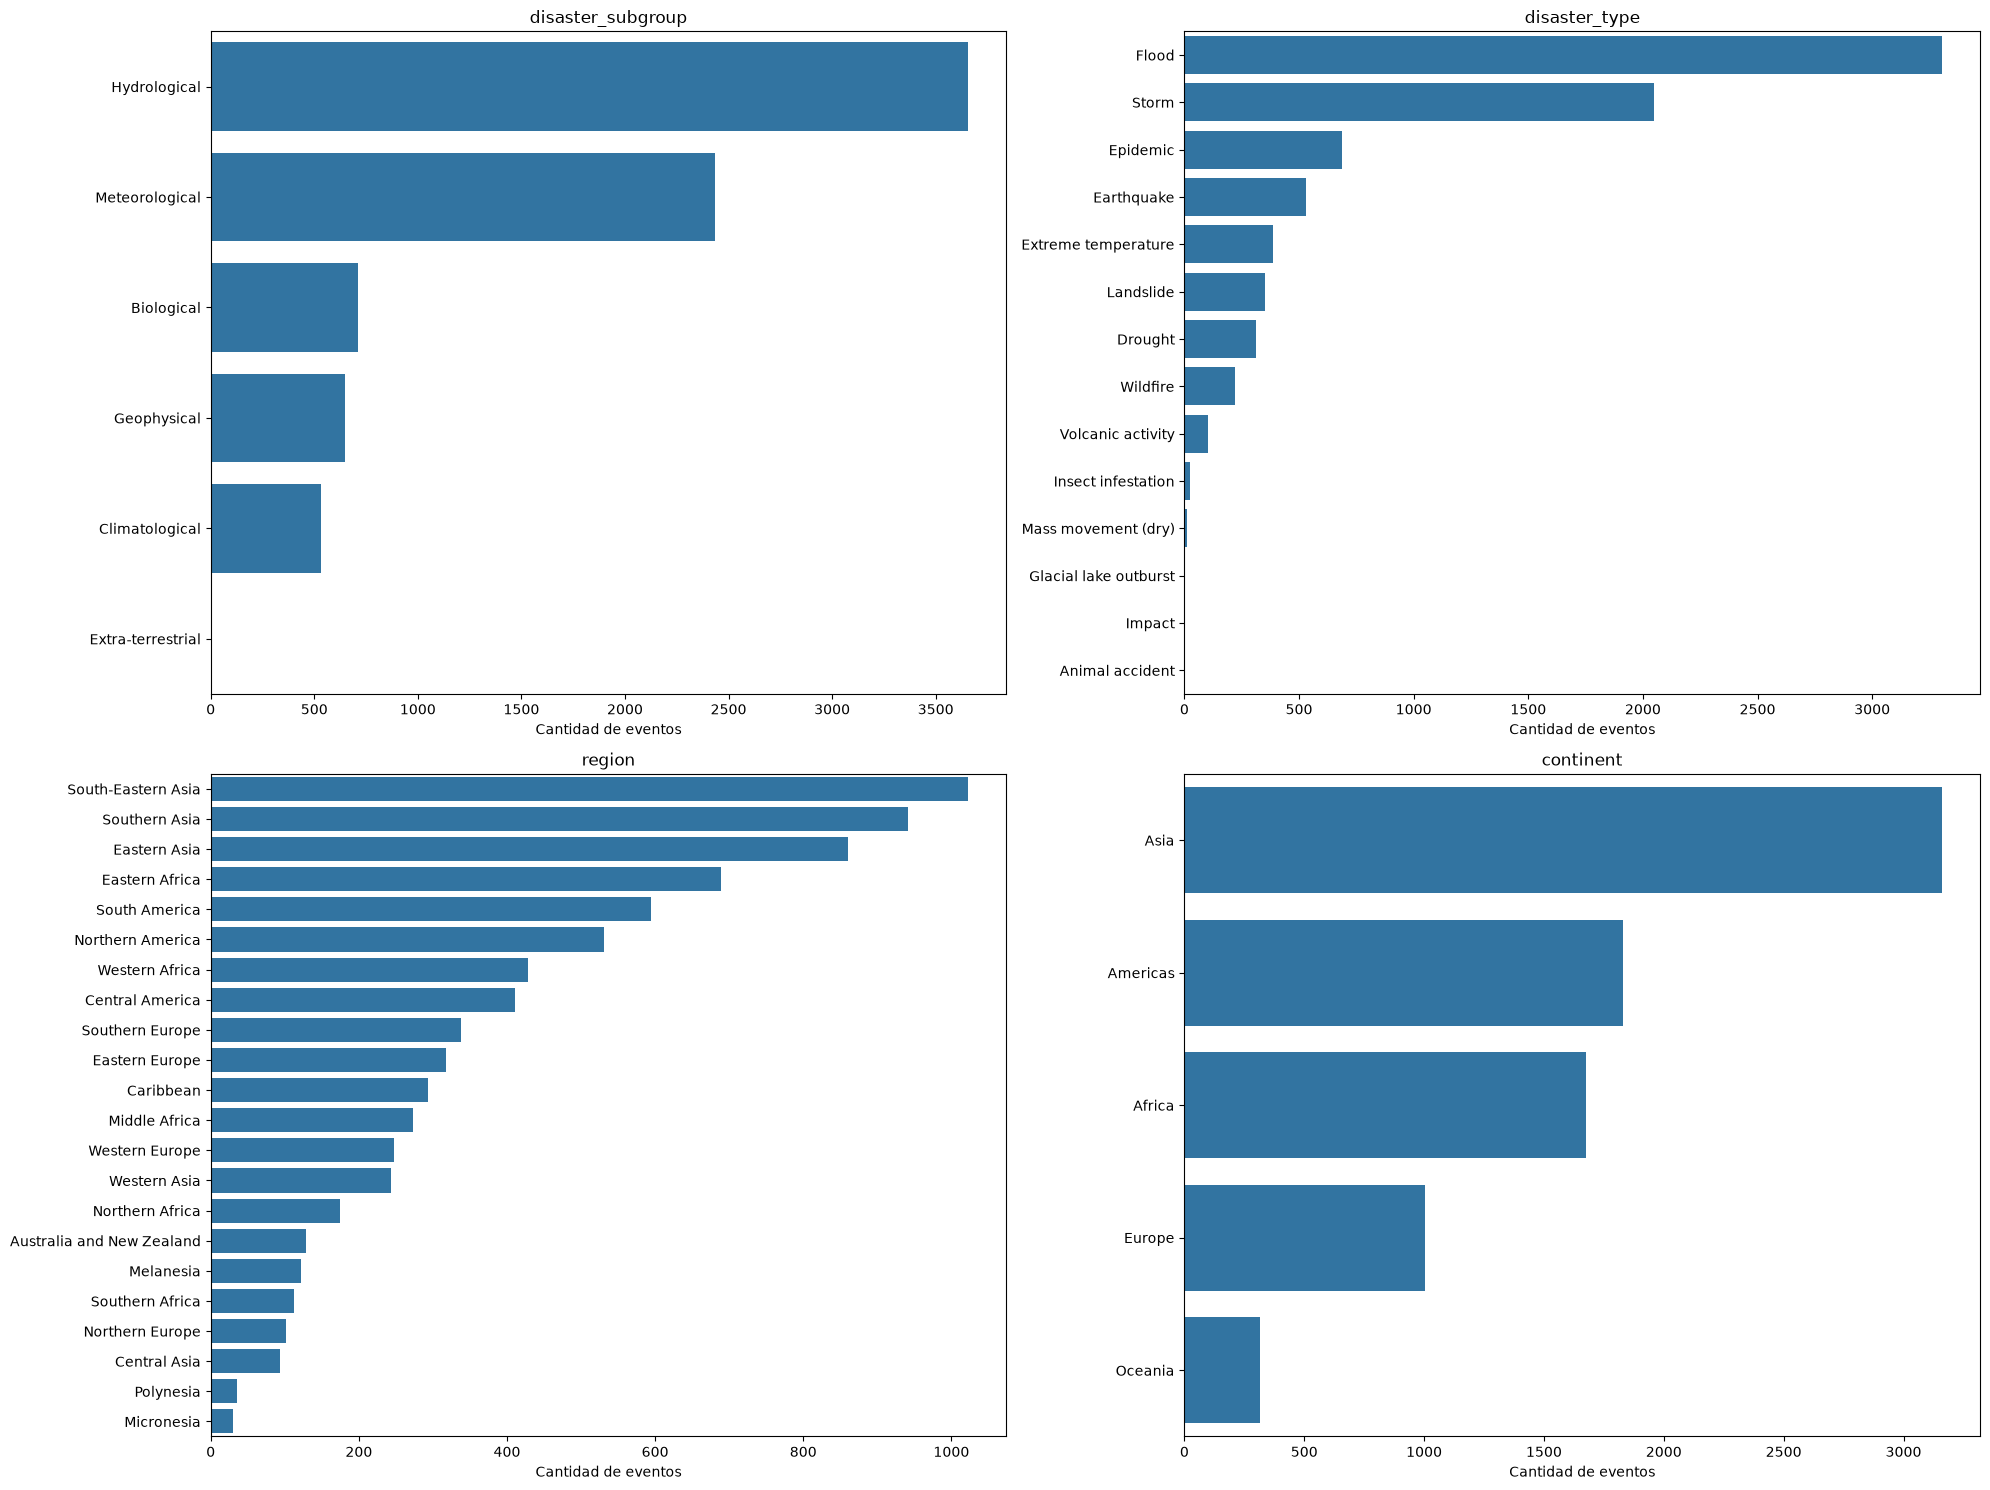

In [224]:
columnas = ["disaster_subgroup", "disaster_type", "region", "continent"]

fig, axes = plt.subplots(2, 2, figsize=(20, 15))  
axes = axes.flatten()  # para poder recorrerlas con un solo for

for i, columna in enumerate(columnas):
    orden = df_analisis[columna].value_counts().index
    sns.countplot(data=df_analisis, y=columna, order=orden, ax=axes[i])
    axes[i].set_title(columna)
    axes[i].set_xlabel("Cantidad de eventos")
    axes[i].set_ylabel("")

for j in range(len(columnas), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()

In [232]:
df_analisis[df_analisis["disaster_type"] == "Epidemic"]

,disaster_subgroup,disaster_type,country,region,continent,fecha
16,Biological,Epidemic,Afghanistan,Southern Asia,Asia,2002-09-01
17,Biological,Epidemic,Afghanistan,Southern Asia,Asia,2002-01-01
18,Biological,Epidemic,Afghanistan,Southern Asia,Asia,2002-03-01
20,Biological,Epidemic,Afghanistan,Southern Asia,Asia,2002-03-28
21,Biological,Epidemic,Afghanistan,Southern Asia,Asia,2002-04-10
...,...,...,...,...,...,...
7866,Biological,Epidemic,Congo (the Democratic Republic of the),Middle Africa,Africa,2019-01-01
7867,Biological,Epidemic,Congo (the Democratic Republic of the),Middle Africa,Africa,2019-01-01
7913,Biological,Epidemic,Saint Vincent and the Grenadines,Caribbean,Americas,2020-10-01
7926,Biological,Epidemic,Congo (the Democratic Republic of the),Middle Africa,Africa,2020-06-01


In [231]:
df_analisis[df_analisis["disaster_subgroup"] == "Extra-terrestrial"]

,disaster_subgroup,disaster_type,country,region,continent,fecha
4907,Extra-terrestrial,Impact,Russian Federation (the),Eastern Europe,Europe,2013-02-15


Text(0.5, 0, 'Cantidad de eventos')

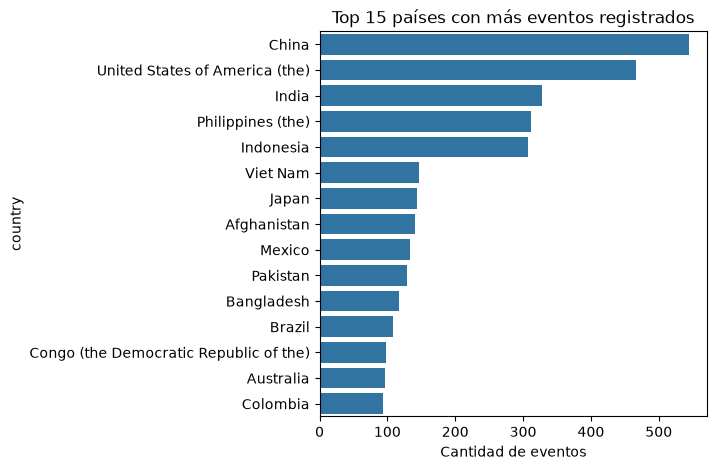

In [226]:
fig, ax = plt.subplots(figsize=(5, 5))
top_paises = df_analisis["country"].value_counts().head(15)
sns.barplot(x=top_paises.values, y=top_paises.index, ax=ax)
ax.set_title("Top 15 países con más eventos registrados")
ax.set_xlabel("Cantidad de eventos")

nota

disaster_type tiene 14 categorías, algunas muy poco frecuentes ("Animal accident", "Impact", "Glacial lake outburst"). 
Para que los gráficos de cruces no queden ilegibles con barras minúsculas, podés considerar quedarte con los 5-6 tipos más frecuentes y agrupar el resto como "Otros", o simplemente ordenarlos por frecuencia en el gráfico (order=value_counts().index, como vimos antes).
region tiene 22 valores, bastante granular. Para el cruce de disaster_type × ubicación, probablemente continent (5 valores) dé un gráfico más legible que region (22 valores), aunque region puede servir para el cruce de disaster_subgroup × region si querés algo más detallado.

-----------------------------------------------------------------------------------------------------------------

## Reporte analítico que identifique patrones estacionales en la ocurrencia de los eventos analizados

In [234]:
# Cantidad de eventos por mes (estacionalidad), sobre el período reciente

por_mes = df_analisis.groupby(df_analisis["fecha"].dt.month).size().reset_index()
por_mes.columns = ["mes", "cantidad_eventos"]

C:\Users\soljo\AppData\Local\Temp\ipykernel_21844\3249482766.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(MESES, rotation=0)


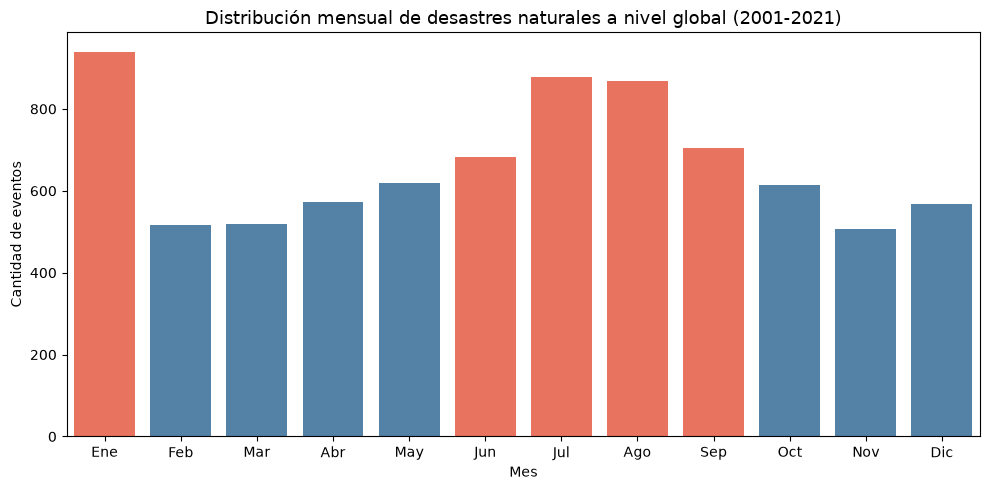

In [239]:
MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

# color rojo para las barras que superan el valor promedio 
colores = ["tomato" if valor > por_mes["cantidad_eventos"].mean() else "steelblue" for valor in por_mes["cantidad_eventos"]]

fig, ax = plt.subplots(figsize=(10, 5))

barras_mes = sns.barplot(
    data=por_mes,
    x = por_mes['mes'],
    y = por_mes['cantidad_eventos'],
    hue = 'mes',
    legend=False,
    palette=colores,
    ax=ax)

ax.set_xticklabels(MESES, rotation=0)
ax.set_title("Distribución mensual de desastres naturales a nivel global (2001-2021)", fontsize=13)
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de eventos")

fig.tight_layout()

### Detalle del tipo y cantidad de eventos sucedidos, en los meses que superan el promedio de eventos

In [ ]:
print('------------- Enero -------------')
enero = df_analisis[df_analisis["fecha"].dt.month == 1]
print(enero["disaster_type"].value_counts().head())
print('------------------------------------------------')
print('------------- Julio -------------')
julio = df_analisis[df_analisis["fecha"].dt.month == 7]
print(julio["disaster_type"].value_counts().head())
print('------------------------------------------------')
print('------------- Marzo -------------')
enero = df_analisis[df_analisis["fecha"].dt.month == 3]
print(enero["disaster_type"].value_counts().head())
print('------------------------------------------------')
print('------------- Noviembre -------------')
julio = df_analisis[df_analisis["fecha"].dt.month == 11]
print(julio["disaster_type"].value_counts().head())

Enero
disaster_type
Flood                  256
Storm                  219
Epidemic               185
Extreme temperature     95
Drought                 72
Name: count, dtype: int64
------------------------------------------------
Julio
disaster_type
Flood                  388
Storm                  168
Extreme temperature     81
Wildfire                54
Epidemic                51
Name: count, dtype: int64
------------------------------------------------
Marzo
disaster_type
Flood         234
Storm         128
Earthquake     44
Epidemic       39
Landslide      26
Name: count, dtype: int64
------------------------------------------------
Noviembre
disaster_type
Flood                  219
Storm                  133
Earthquake              48
Epidemic                30
Extreme temperature     23
Name: count, dtype: int64


### Patrones estacionales en la ocurrencia de desastres naturales (2001-2021)

La distribución mensual global muestra dos picos: enero (938 eventos) y 
julio-agosto (879 y 868 eventos). El pico de julio-agosto es explicable por 
la estacionalidad climática del hemisferio norte (mayor frecuencia de 
temperaturas extremas e incendios forestales, sumado a un pico de 
inundaciones).

El pico de enero combina dos factores. Por un lado, Flood y Storm siguen 
siendo los tipos predominantes, igual que en el resto del año. Por otro, se 
observa una sobrerrepresentación de eventos de tipo Epidemic (185 casos, 
tercer lugar, contra solo 51 en julio), que no responde a estacionalidad 
climática sino, probablemente, a la forma en que se reportan y consolidan 
administrativamente los brotes epidémicos, muchas veces sistematizados al 
cierre o inicio del año calendario.

Descartada ademas una contaminacion de los datos por parte de la imputacion ya que para la columna de mes la decision fue imputar con un muestrreo aleatorio poderado y no con fillna(1) que provocaría un aumento de registros artificial par el mes de Enero

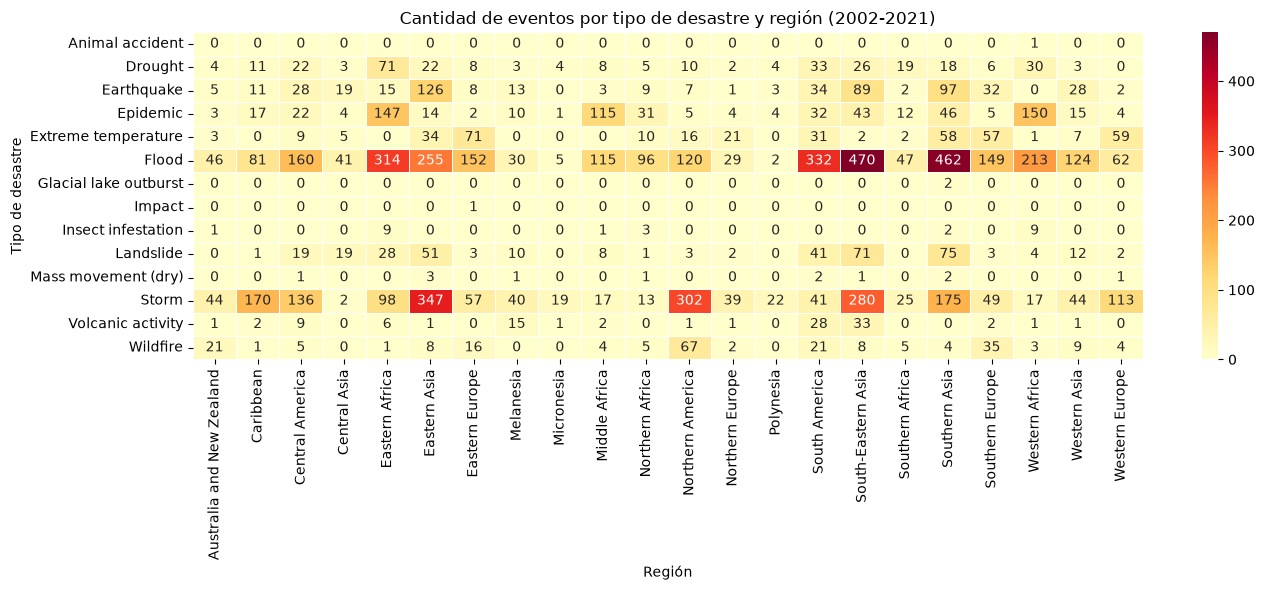

In [ ]:
tabla_tipo_region = df_analisis.pivot_table(
    index="disaster_type",
    columns="region",
    values="fecha",  # cualquier columna sirve, solo se usa para contar
    aggfunc="count",
    fill_value=0
)

# heatmap 
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    tabla_tipo_region,
    cmap="YlOrRd",
    annot=True,      # escribe el número dentro de cada celda
    fmt="d",          # formato entero (sin decimales)
    linewidths=0.5,   # líneas finas entre celdas, para que se lean mejor
    ax=ax
)

ax.set_title("Cantidad de eventos por tipo de desastre y región (2002-2021)")
ax.set_xlabel("Región")
ax.set_ylabel("Tipo de desastre")
ax.tick_params(axis="x", rotation=90)

fig.tight_layout()

## Cruces
* Disaster Type × Continent: qué tipo de desastre predomina en cada continente
* Disaster Type × mes en continente (estacionalidad): ya tenés fecha, así que es directo
* Total Deaths promedio por Disaster Type: aclarando que se calcula solo sobre los casos que reportaron el dato (tiene muchos nulos).
* Disaster Type × año: tendencia de cada tipo en las últimas dos décadas.